
Weather History   

The goal of this project is to explore, analyze, and visualize weather data to gain insights into temperature trends, humidity, wind speed, visibility, and other key meteorological variables. Additionally, we aim to identify relationships between variables and detect any anomalies or patterns over time.

In [12]:
#  pandas library for data manipulation and analysis.
import pandas as pd  

#  numpy library for numerical operations and array manipulation.
import numpy as np  

#  stats module from the scipy library for statistical functions.
from scipy import stats  

#  matplotlib library for creating static, animated, and interactive visualizations.
import matplotlib.pyplot as plt  

#  seaborn library for advanced data visualization based on matplotlib.
import seaborn as sns  


The engine='python' parameter in pd.read_csv() tells pandas to use Python’s built-in CSV parsing engine
python engine can help with unusual cases related to newline or encoding issues for several reasons: Newline Variability , Custom Delimiters and Encodings and Error Handling .

In [13]:
 # Load the dataset from the specified file path with proper encoding for special characters.
data = pd.read_csv(r"weatherHistory.csv", encoding='ISO-8859-1', engine='python')
 
 # Convert the loaded data into a DataFrame.
df = pd.DataFrame(data)

# Display the first few rows of the DataFrame to check the structure of the data.
df.head()


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


1- Data Exploration 

- The dataset contains historical weather data with the following key features.

In [14]:
# Shape of the dataset (rows, columns)
print("Shape:", df.shape)


Shape: (96453, 12)


In [15]:
# Column names
print("Columns:", df.columns)

Columns: Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')


In [16]:
# Quick summary of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB
None


In [17]:
# Basic statistics for numeric columns
print(df.describe())

       Temperature (C)  Apparent Temperature (C)      Humidity  \
count     96453.000000              96453.000000  96453.000000   
mean         11.932678                 10.855029      0.734899   
std           9.551546                 10.696847      0.195473   
min         -21.822222                -27.716667      0.000000   
25%           4.688889                  2.311111      0.600000   
50%          12.000000                 12.000000      0.780000   
75%          18.838889                 18.838889      0.890000   
max          39.905556                 39.344444      1.000000   

       Wind Speed (km/h)  Wind Bearing (degrees)  Visibility (km)  Loud Cover  \
count       96453.000000            96453.000000     96453.000000     96453.0   
mean           10.810640              187.509232        10.347325         0.0   
std             6.913571              107.383428         4.192123         0.0   
min             0.000000                0.000000         0.000000         0.0   


In [18]:
# Count of missing values per column
print(df.isnull().sum())

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


In [19]:
# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# View duplicate rows
print(df[df.duplicated()])


Number of duplicate rows: 24
                      Formatted Date        Summary Precip Type  \
36072  2010-08-02 00:00:00.000 +0200          Clear        rain   
36073  2010-08-02 01:00:00.000 +0200          Clear        rain   
36074  2010-08-02 02:00:00.000 +0200          Clear        rain   
36075  2010-08-02 03:00:00.000 +0200          Clear        rain   
36076  2010-08-02 04:00:00.000 +0200          Clear        rain   
36077  2010-08-02 05:00:00.000 +0200          Clear        rain   
36078  2010-08-02 06:00:00.000 +0200          Clear        rain   
36079  2010-08-02 07:00:00.000 +0200          Clear        rain   
36080  2010-08-02 08:00:00.000 +0200          Clear        rain   
36081  2010-08-02 09:00:00.000 +0200          Clear        rain   
36082  2010-08-02 10:00:00.000 +0200          Clear        rain   
36083  2010-08-02 11:00:00.000 +0200          Clear        rain   
36084  2010-08-02 12:00:00.000 +0200          Clear        rain   
36085  2010-08-02 13:00:00.000 +0

In [20]:
# Print the number of unique values in each column of the DataFrame
print(df.nunique())

Formatted Date              96429
Summary                        27
Precip Type                     2
Temperature (C)              7574
Apparent Temperature (C)     8984
Humidity                       90
Wind Speed (km/h)            2484
Wind Bearing (degrees)        360
Visibility (km)               949
Loud Cover                      1
Pressure (millibars)         4979
Daily Summary                 214
dtype: int64


Random sample of 'Daily Summary' values (size: 30):
25072                           Mostly cloudy until night.
76991    Foggy starting overnight continuing until morn...
22153                                Foggy in the morning.
38576                                Foggy in the morning.
82949             Partly cloudy starting in the afternoon.
76329               Partly cloudy starting in the morning.
76376                    Mostly cloudy throughout the day.
1413                     Mostly cloudy throughout the day.
62787    Partly cloudy starting in the afternoon contin...
57802               Partly cloudy starting in the morning.
65911                    Partly cloudy throughout the day.
226                             Partly cloudy until night.
47047                         Overcast throughout the day.
93825                    Partly cloudy throughout the day.
66115                           Partly cloudy until night.
65784                    Mostly cloudy throughout the day.
6743

C:\Users\fares\AppData\Local\Temp\ipykernel_4936\3102196713.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Daily Summary", data=df[df["Daily Summary"].isin(data_sample)], palette="icefire")


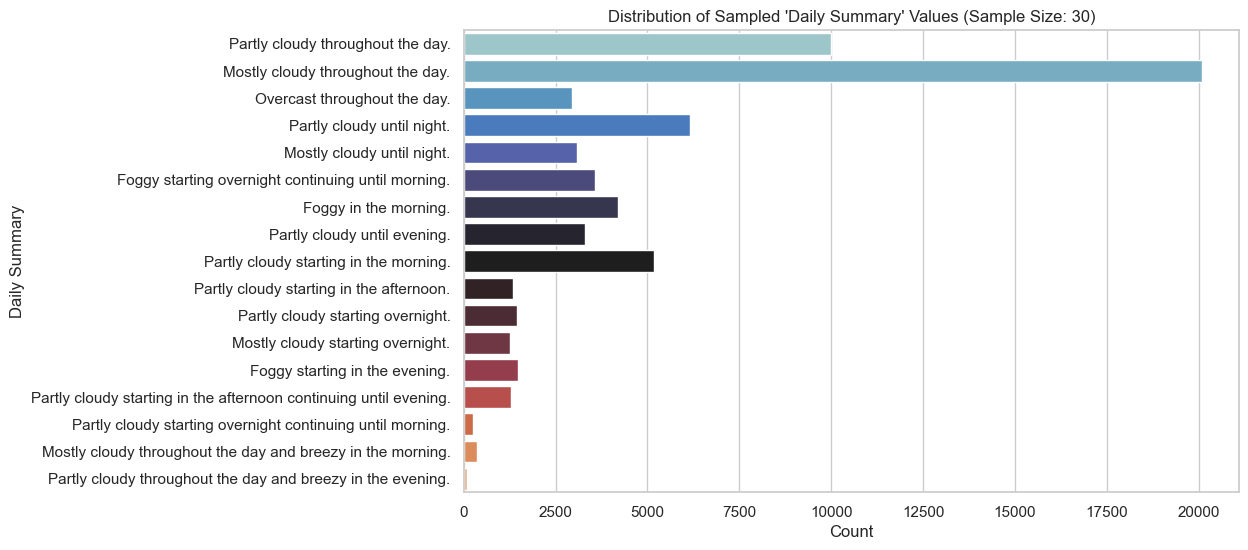

In [46]:
#Explore Categorical Variables

# Display a random sample of data from the column

sample_size = 30  # Number of rows to display
data_sample = df["Daily Summary"].sample(n=sample_size, random_state=42)  # Random seed for reproducibility
print(f"Random sample of 'Daily Summary' values (size: {sample_size}):")
print(data_sample)

# Visualize the distribution for the sample
plt.figure(figsize=(10, 6))
sns.countplot(y="Daily Summary", data=df[df["Daily Summary"].isin(data_sample)], palette="icefire")
plt.title(f"Distribution of Sampled 'Daily Summary' Values (Sample Size: {sample_size})")
plt.xlabel("Count")
plt.ylabel("Daily Summary")
plt.show()


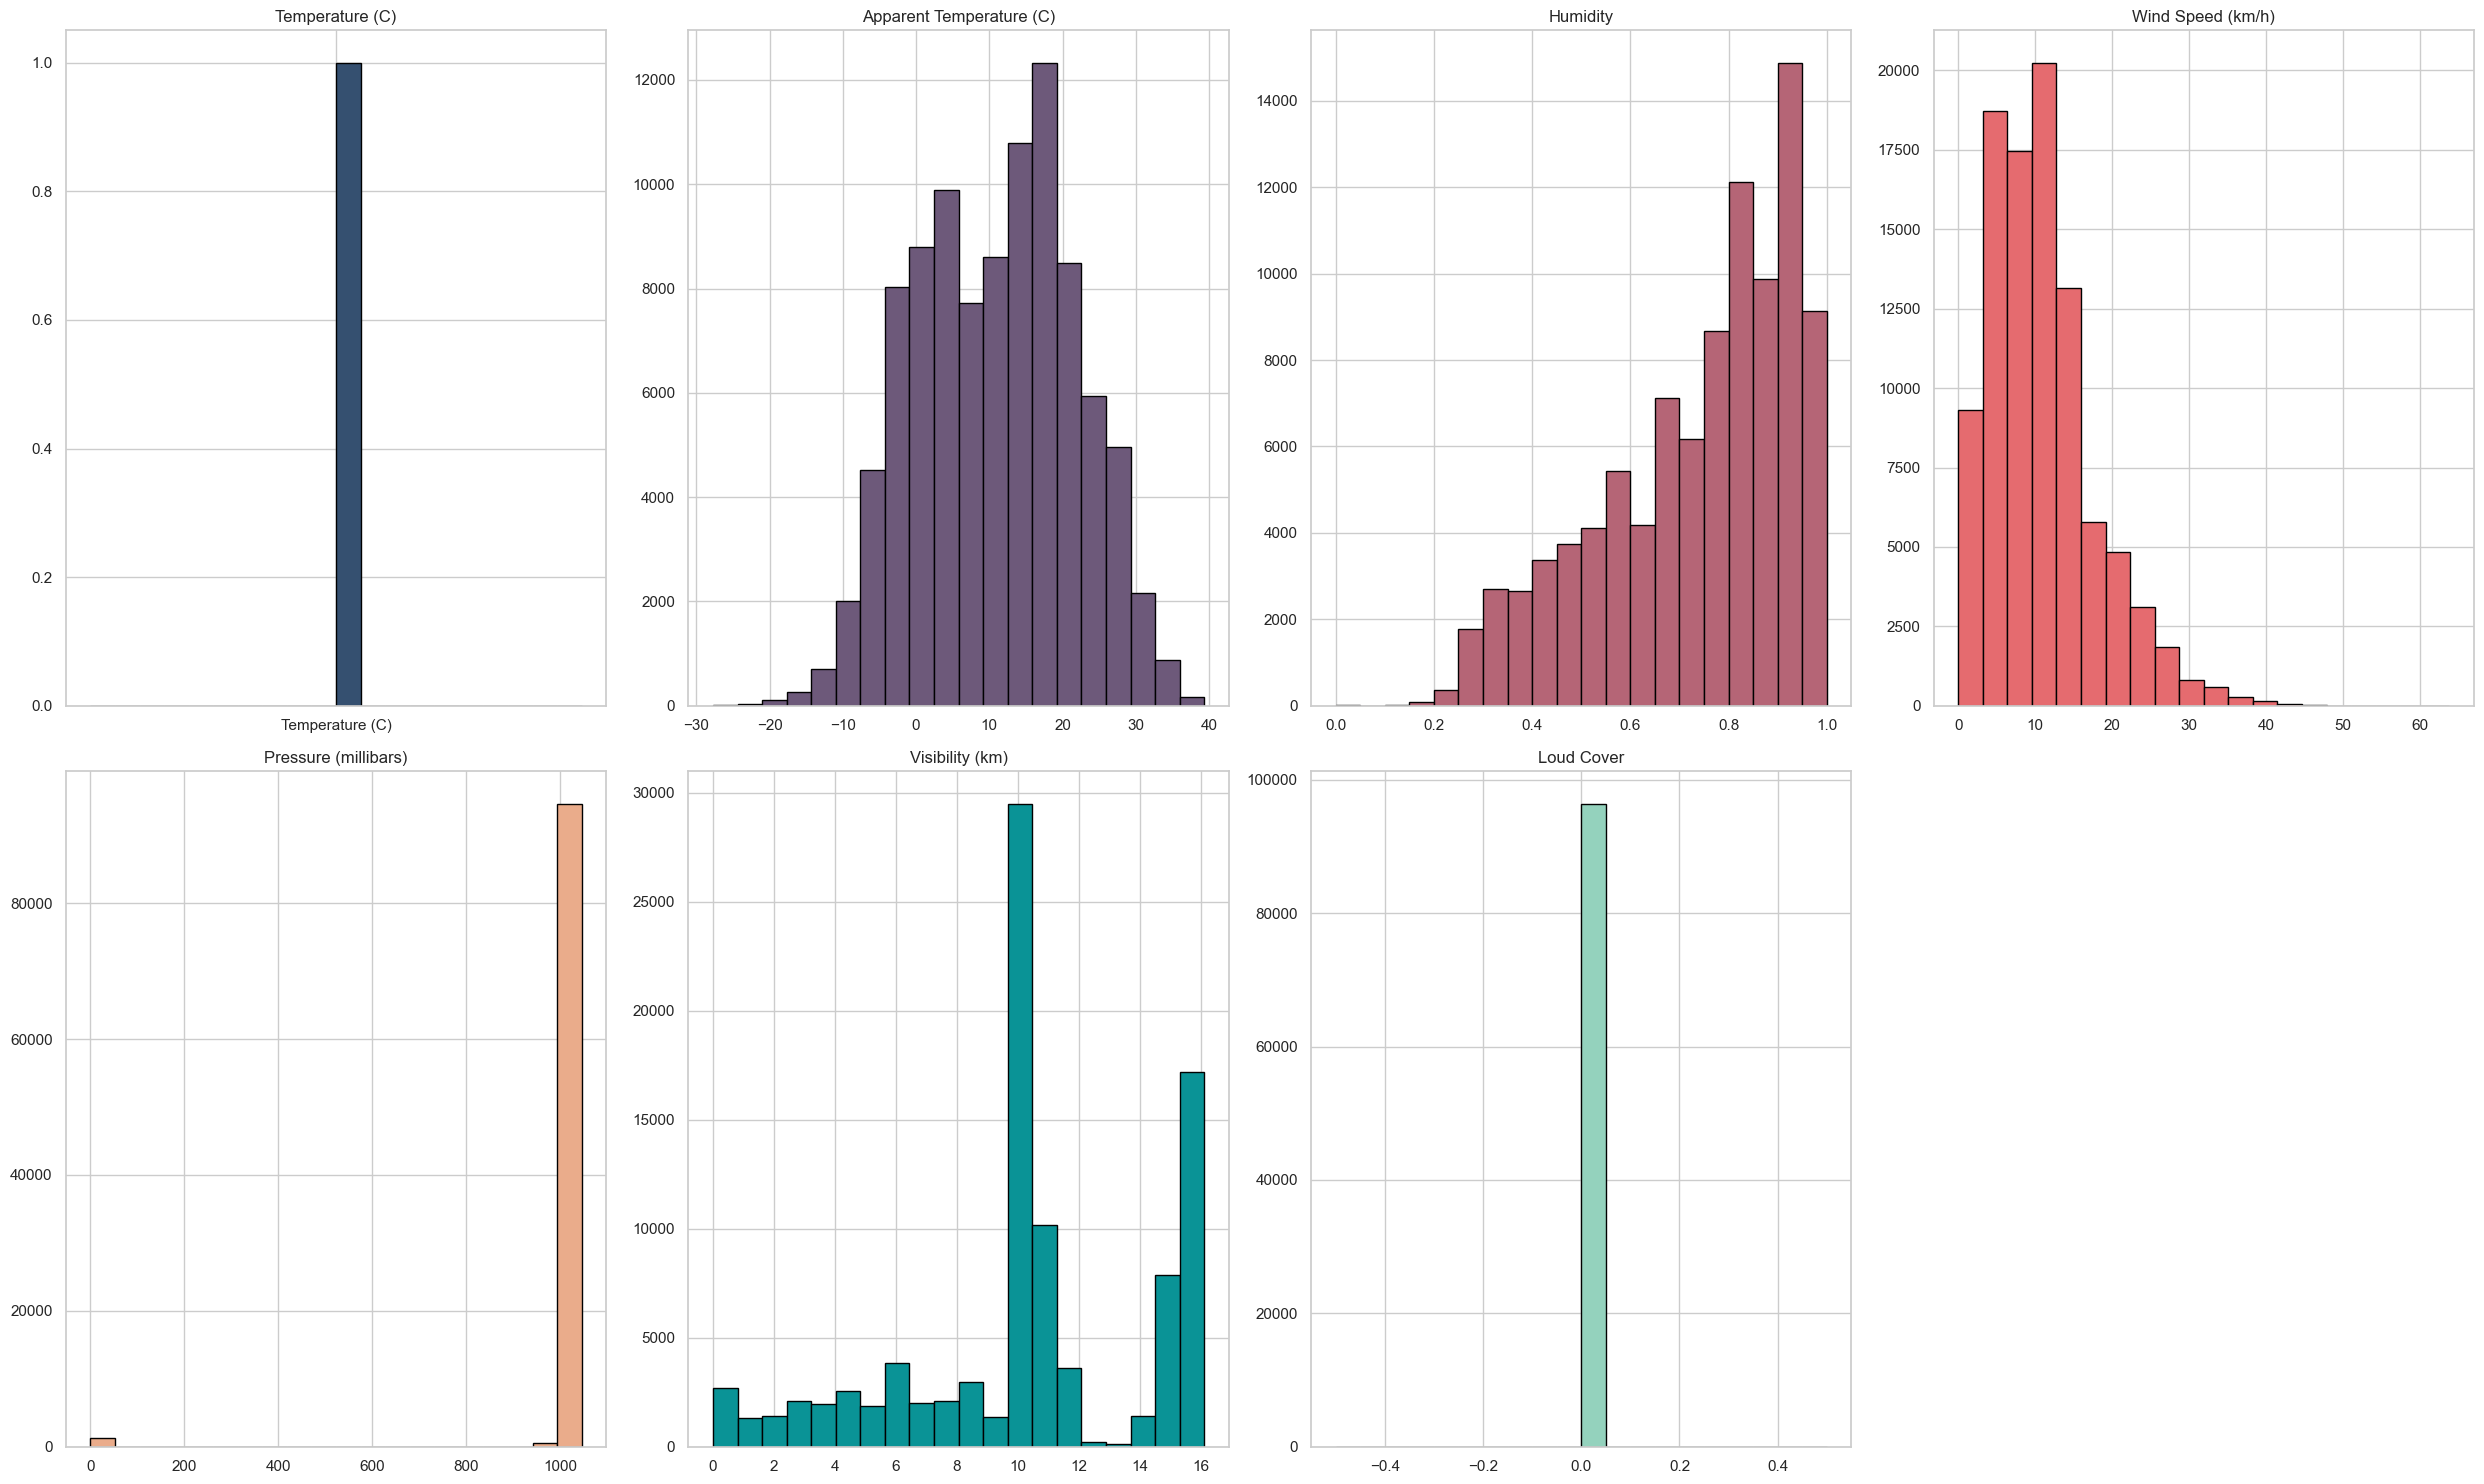

In [ ]:
# Generating histograms for seven numerical columns from a DataFrame to visualize their distributions.

numerical_columns = ["Temperature (C)", "Apparent Temperature (C)", "Humidity", "Wind Speed (km/h)", "Pressure (millibars)", "Visibility (km)", "Loud Cover"]

# Create subplots for 7 histograms
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2 rows, 4 columns

# Plot histograms for each column
axes[0, 0].hist(["Temperature (C)"], bins=20, color="#355070", edgecolor="black")
axes[0, 0].set_title("Temperature (C)")

axes[0, 1].hist(df["Apparent Temperature (C)"], bins=20, color="#6d597a", edgecolor="black")
axes[0, 1].set_title("Apparent Temperature (C)")

axes[0, 2].hist(df["Humidity"], bins=20, color="#b56576", edgecolor="black")
axes[0, 2].set_title("Humidity")

axes[0, 3].hist(df["Wind Speed (km/h)"], bins=20, color="#e56b6f", edgecolor="black")
axes[0, 3].set_title("Wind Speed (km/h)")

axes[1, 0].hist(df["Pressure (millibars)"], bins=20, color="#eaac8b", edgecolor="black")
axes[1, 0].set_title("Pressure (millibars)")

axes[1, 1].hist(df["Visibility (km)"], bins=20, color="#0a9396", edgecolor="black")
axes[1, 1].set_title("Visibility (km)")

axes[1, 2].hist(df["Loud Cover"], bins=20, color="#94d2bd", edgecolor="black")
axes[1, 2].set_title("Loud Cover")

# Hide the empty subplot
axes[1, 3].axis('off')  # Turn off the unused subplot

# Adjust layout
plt.tight_layout()
plt.show()


In [23]:
# identifies numerical columns in the dataset and detects outliers using the Interquartile Range (IQR) method.

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for numerical columns
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

# Calculate the IQR (Interquartile Range) for numerical columns
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers for each numerical column
outliers = ((df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound))

# Display columns with outliers
outlier_columns = outliers.any()
print(outlier_columns[outlier_columns == True])  # This will show columns with outliers


Temperature (C)             True
Apparent Temperature (C)    True
Humidity                    True
Wind Speed (km/h)           True
Pressure (millibars)        True
dtype: bool


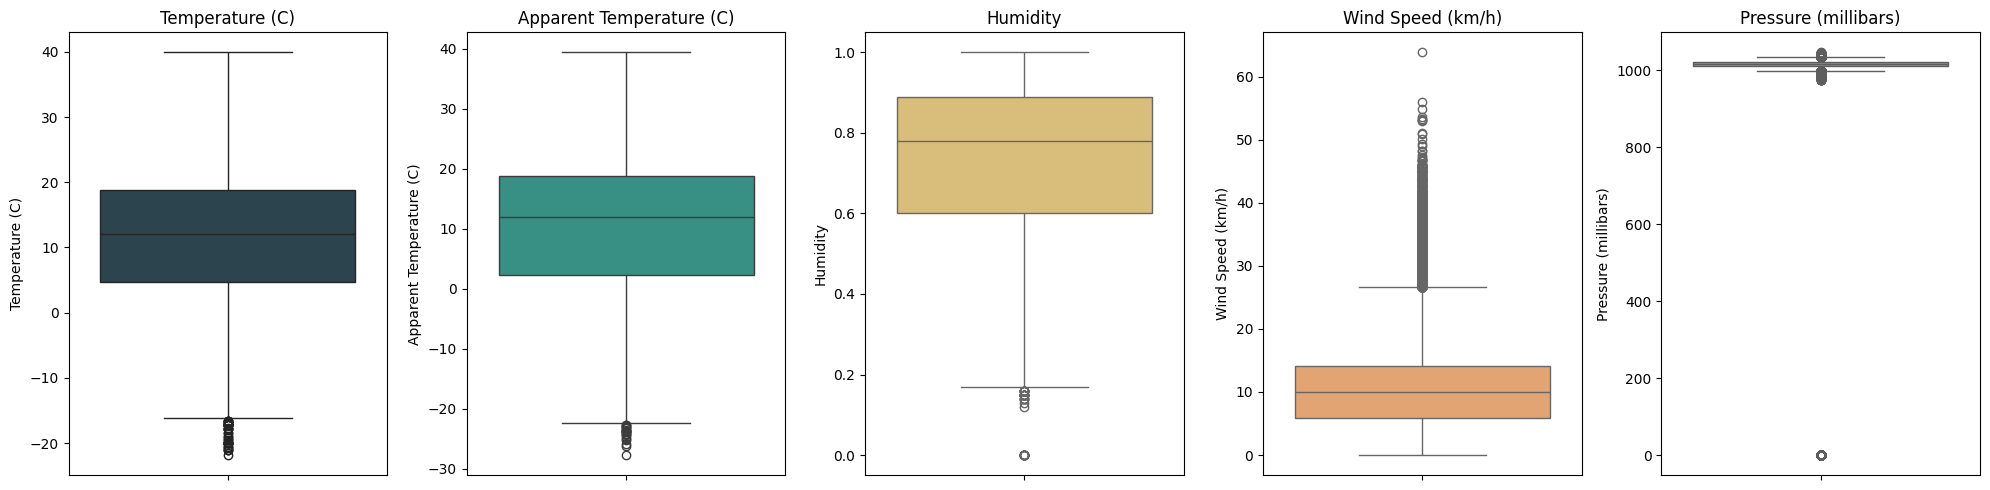

In [24]:
# outliers
fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # 1 row, 5 columns

# Boxplots for individual variables
sns.boxplot(data=df["Temperature (C)"], color="#264653", ax=axes[0])
axes[0].set_title("Temperature (C)")

sns.boxplot(data=df["Apparent Temperature (C)"], color="#2a9d8f", ax=axes[1])
axes[1].set_title("Apparent Temperature (C)")

sns.boxplot(data=df["Humidity"], color="#e9c46a", ax=axes[2])
axes[2].set_title("Humidity")

sns.boxplot(data=df["Wind Speed (km/h)"], color="#f4a261", ax=axes[3])
axes[3].set_title("Wind Speed (km/h)")

sns.boxplot(data=df["Pressure (millibars)"], color="#e76f51", ax=axes[4])
axes[4].set_title("Pressure (millibars)")

# Adjust layout
plt.tight_layout()
plt.show()


2- Data Preprocessing

- Handling Missing Values: Missing values in the ‘Precip Type’ column were replaced with ‘Unknown.’ Other columns had no significant missing data.

- Duplicates: Duplicate rows were identified and removed.

- Data Types: The ‘Formatted Date’ column was converted to a datetime format for easier time-based analysis.

- Outlier Detection: Numerical columns were examined for outliers using the IQR method, and these outliers were removed for cleaner analysis.

In [25]:

#  fill rows with 'UnKnown' for missing values
df['Precip Type'] = df['Precip Type'].fillna('Unknown')

# Check if missing values are resolved
print(df.isnull().sum())


Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


In [26]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()

# Verify duplicates are removed
print(f"Duplicate rows after cleaning: {df.duplicated().sum()}")


Duplicate rows: 24
Duplicate rows after cleaning: 0


In [27]:
# Investigate Data Types and Format Issues
# Ensure consistency in data types:

# Convert column to the correct data type (e.g., datetime)
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"] , utc=True)

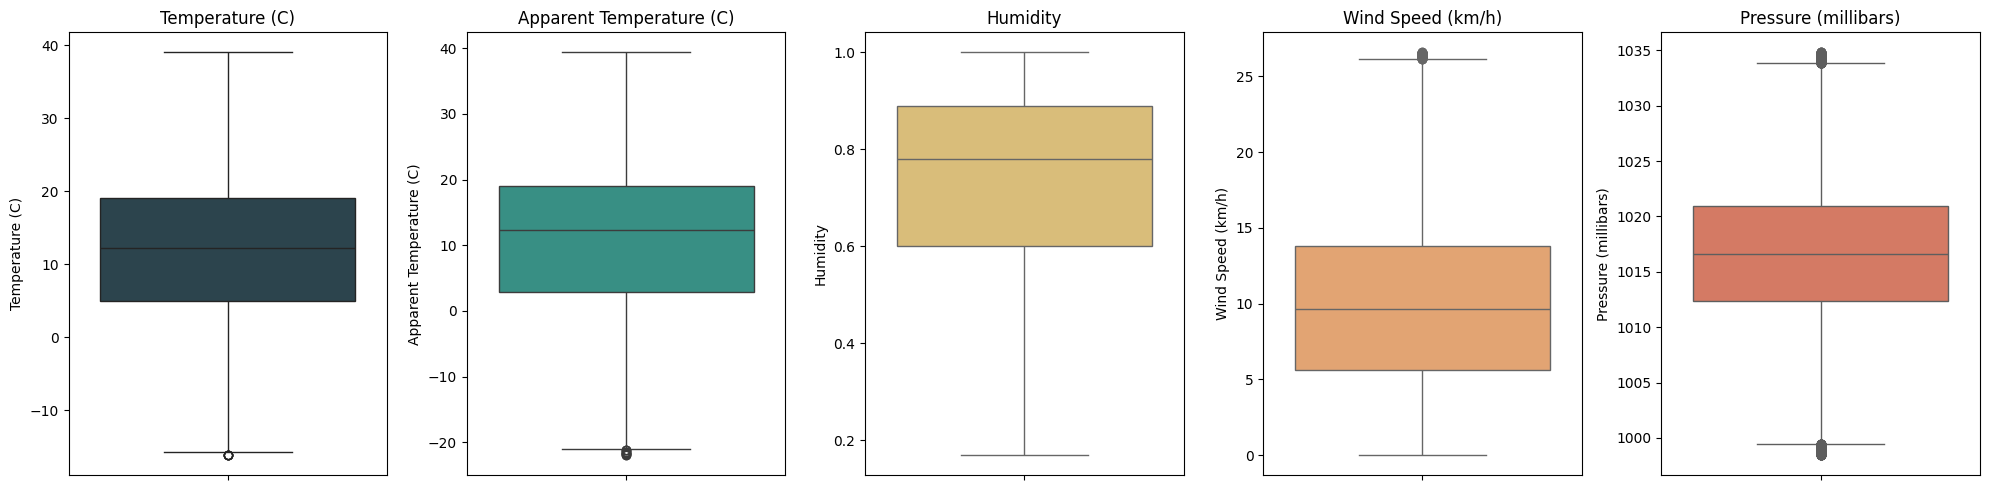

Original data shape: (96429, 12)
Cleaned data shape: (89150, 12)


In [28]:
numerical_columns = ["Temperature (C)", "Apparent Temperature (C)", "Humidity", "Wind Speed (km/h)", "Pressure (millibars)"]

# Function to remove outliers using the IQR method
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)  # First quartile (25th percentile)
        Q3 = df[col].quantile(0.75)  # Third quartile (75th percentile)
        IQR = Q3 - Q1  # Interquartile range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]  # Filter out outliers
    return df

# Remove outliers
df_cleaned = remove_outliers(df, numerical_columns)

# Plot boxplots for cleaned data
fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # 1 row, 5 columns

sns.boxplot(data=df_cleaned["Temperature (C)"], color="#264653", ax=axes[0])
axes[0].set_title("Temperature (C)")

sns.boxplot(data=df_cleaned["Apparent Temperature (C)"], color="#2a9d8f", ax=axes[1])
axes[1].set_title("Apparent Temperature (C)")

sns.boxplot(data=df_cleaned["Humidity"], color="#e9c46a", ax=axes[2])
axes[2].set_title("Humidity")

sns.boxplot(data=df_cleaned["Wind Speed (km/h)"], color="#f4a261", ax=axes[3])
axes[3].set_title("Wind Speed (km/h)")

sns.boxplot(data=df_cleaned["Pressure (millibars)"], color="#e76f51", ax=axes[4])
axes[4].set_title("Pressure (millibars)")

# Adjust layout
plt.tight_layout()
plt.show()

# Check the result
print(f"Original data shape: {df.shape}")
print(f"Cleaned data shape: {df_cleaned.shape}")


In [29]:
# Check for missing values, duplicates, and describe numeric columns
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())


Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64
0
       Temperature (C)  Apparent Temperature (C)      Humidity  \
count     96429.000000              96429.000000  96429.000000   
mean         11.929692                 10.851707      0.734902   
std           9.550492                 10.695743      0.195466   
min         -21.822222                -27.716667      0.000000   
25%           4.683333                  2.311111      0.600000   
50%          12.000000                 12.000000      0.780000   
75%          18.838889                 18.838889      0.890000   
max          39.905556                 39.344444      1.000000   

       Wind Speed (km/h)  Wind

3- Exploratory Data Analysis 

Statistical Overview

The dataset’s statistical summary revealed variability in temperature, humidity, and other parameters, suggesting diverse weather conditions.

The ‘Daily Summary’ column provided insights into qualitative descriptions of weather patterns.

1- Relationship between humidity and apparent temperature :


 - How does humidity impact apparent temperature? 
 - Does high humidity consistently make the apparent temperature feel higher?

In [30]:
correlation = df_cleaned['Humidity'].corr(df_cleaned['Apparent Temperature (C)'])
print(f"Correlation between Humidity and Apparent Temperature (C): {correlation:.2f}")

Correlation between Humidity and Apparent Temperature (C): -0.62


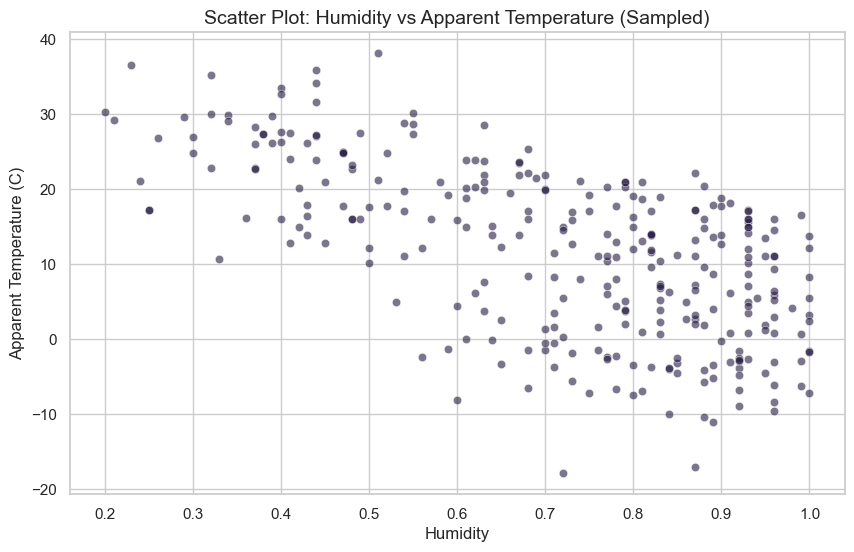

In [31]:
# Define the sample size
dataSample = 300  

# Use double square brackets to select the columns and sample the data
dataSample = df_cleaned[['Humidity', 'Apparent Temperature (C)']].sample(n=dataSample, random_state=42)  # Random seed for reproducibility

# Plot the sampled data
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Humidity', y='Apparent Temperature (C)', data=dataSample, alpha=0.6, color='#231942')  # Use dataSample here
plt.title('Scatter Plot: Humidity vs Apparent Temperature (Sampled)', fontsize=14)
plt.xlabel('Humidity', fontsize=12)
plt.ylabel('Apparent Temperature (C)', fontsize=12)
plt.show()


2- Heatmap for Temperature :


- Daily average temperatures for each month by year to see which months or times of day are consistently warmer or cooler.

- Monthly averages highlighted predictable seasonal patterns in temperature and wind speed, with summer months (June-August) being warmer and winter months (December-February) being colder.


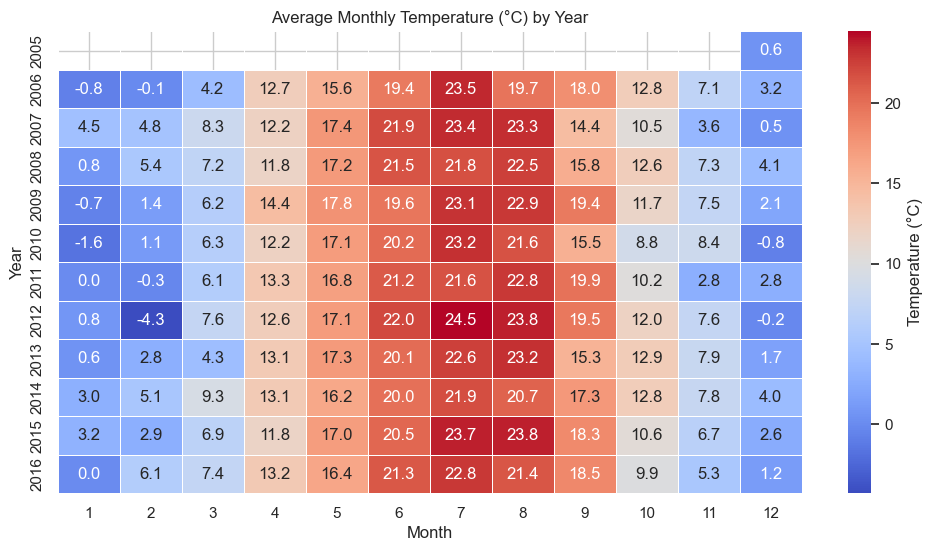

In [32]:
# Extract the year and month from the 'Formatted Date' column
df_cleaned['Year'] = df_cleaned['Formatted Date'].dt.year
df_cleaned['Month'] = df_cleaned['Formatted Date'].dt.month

# Compute the average temperature for each year-month combination
temperature_data = df_cleaned.pivot_table(index='Year', columns='Month', values='Temperature (C)', aggfunc='mean')

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(temperature_data, annot=True, cmap='coolwarm', fmt='.1f', linewidths=0.5, cbar_kws={'label': 'Temperature (°C)'})

# Add labels and title
plt.title('Average Monthly Temperature (°C) by Year')
plt.xlabel('Month')
plt.ylabel('Year')

# Display the heatmap
plt.show()


3- Relationship between actual temperature and apparent temperature :

- How much do they differ?
- Are there months where the difference is particularly large?

Temperature and Apparent Temperature: A strong positive correlation (≈0.99) was observed, indicating that actual temperature and perceived temperature are closely related.


In [33]:
correlation = df_cleaned['Temperature (C)'].corr(df_cleaned['Apparent Temperature (C)'])
print(f"Correlation between Temperature (C) and Apparent Temperature (C): {correlation:.2f}")

Correlation between Temperature (C) and Apparent Temperature (C): 0.99


4- Line plots for monthly average temperatures (2006-2016) displayed a clear seasonal cycle with peaks in summer and troughs in winter.

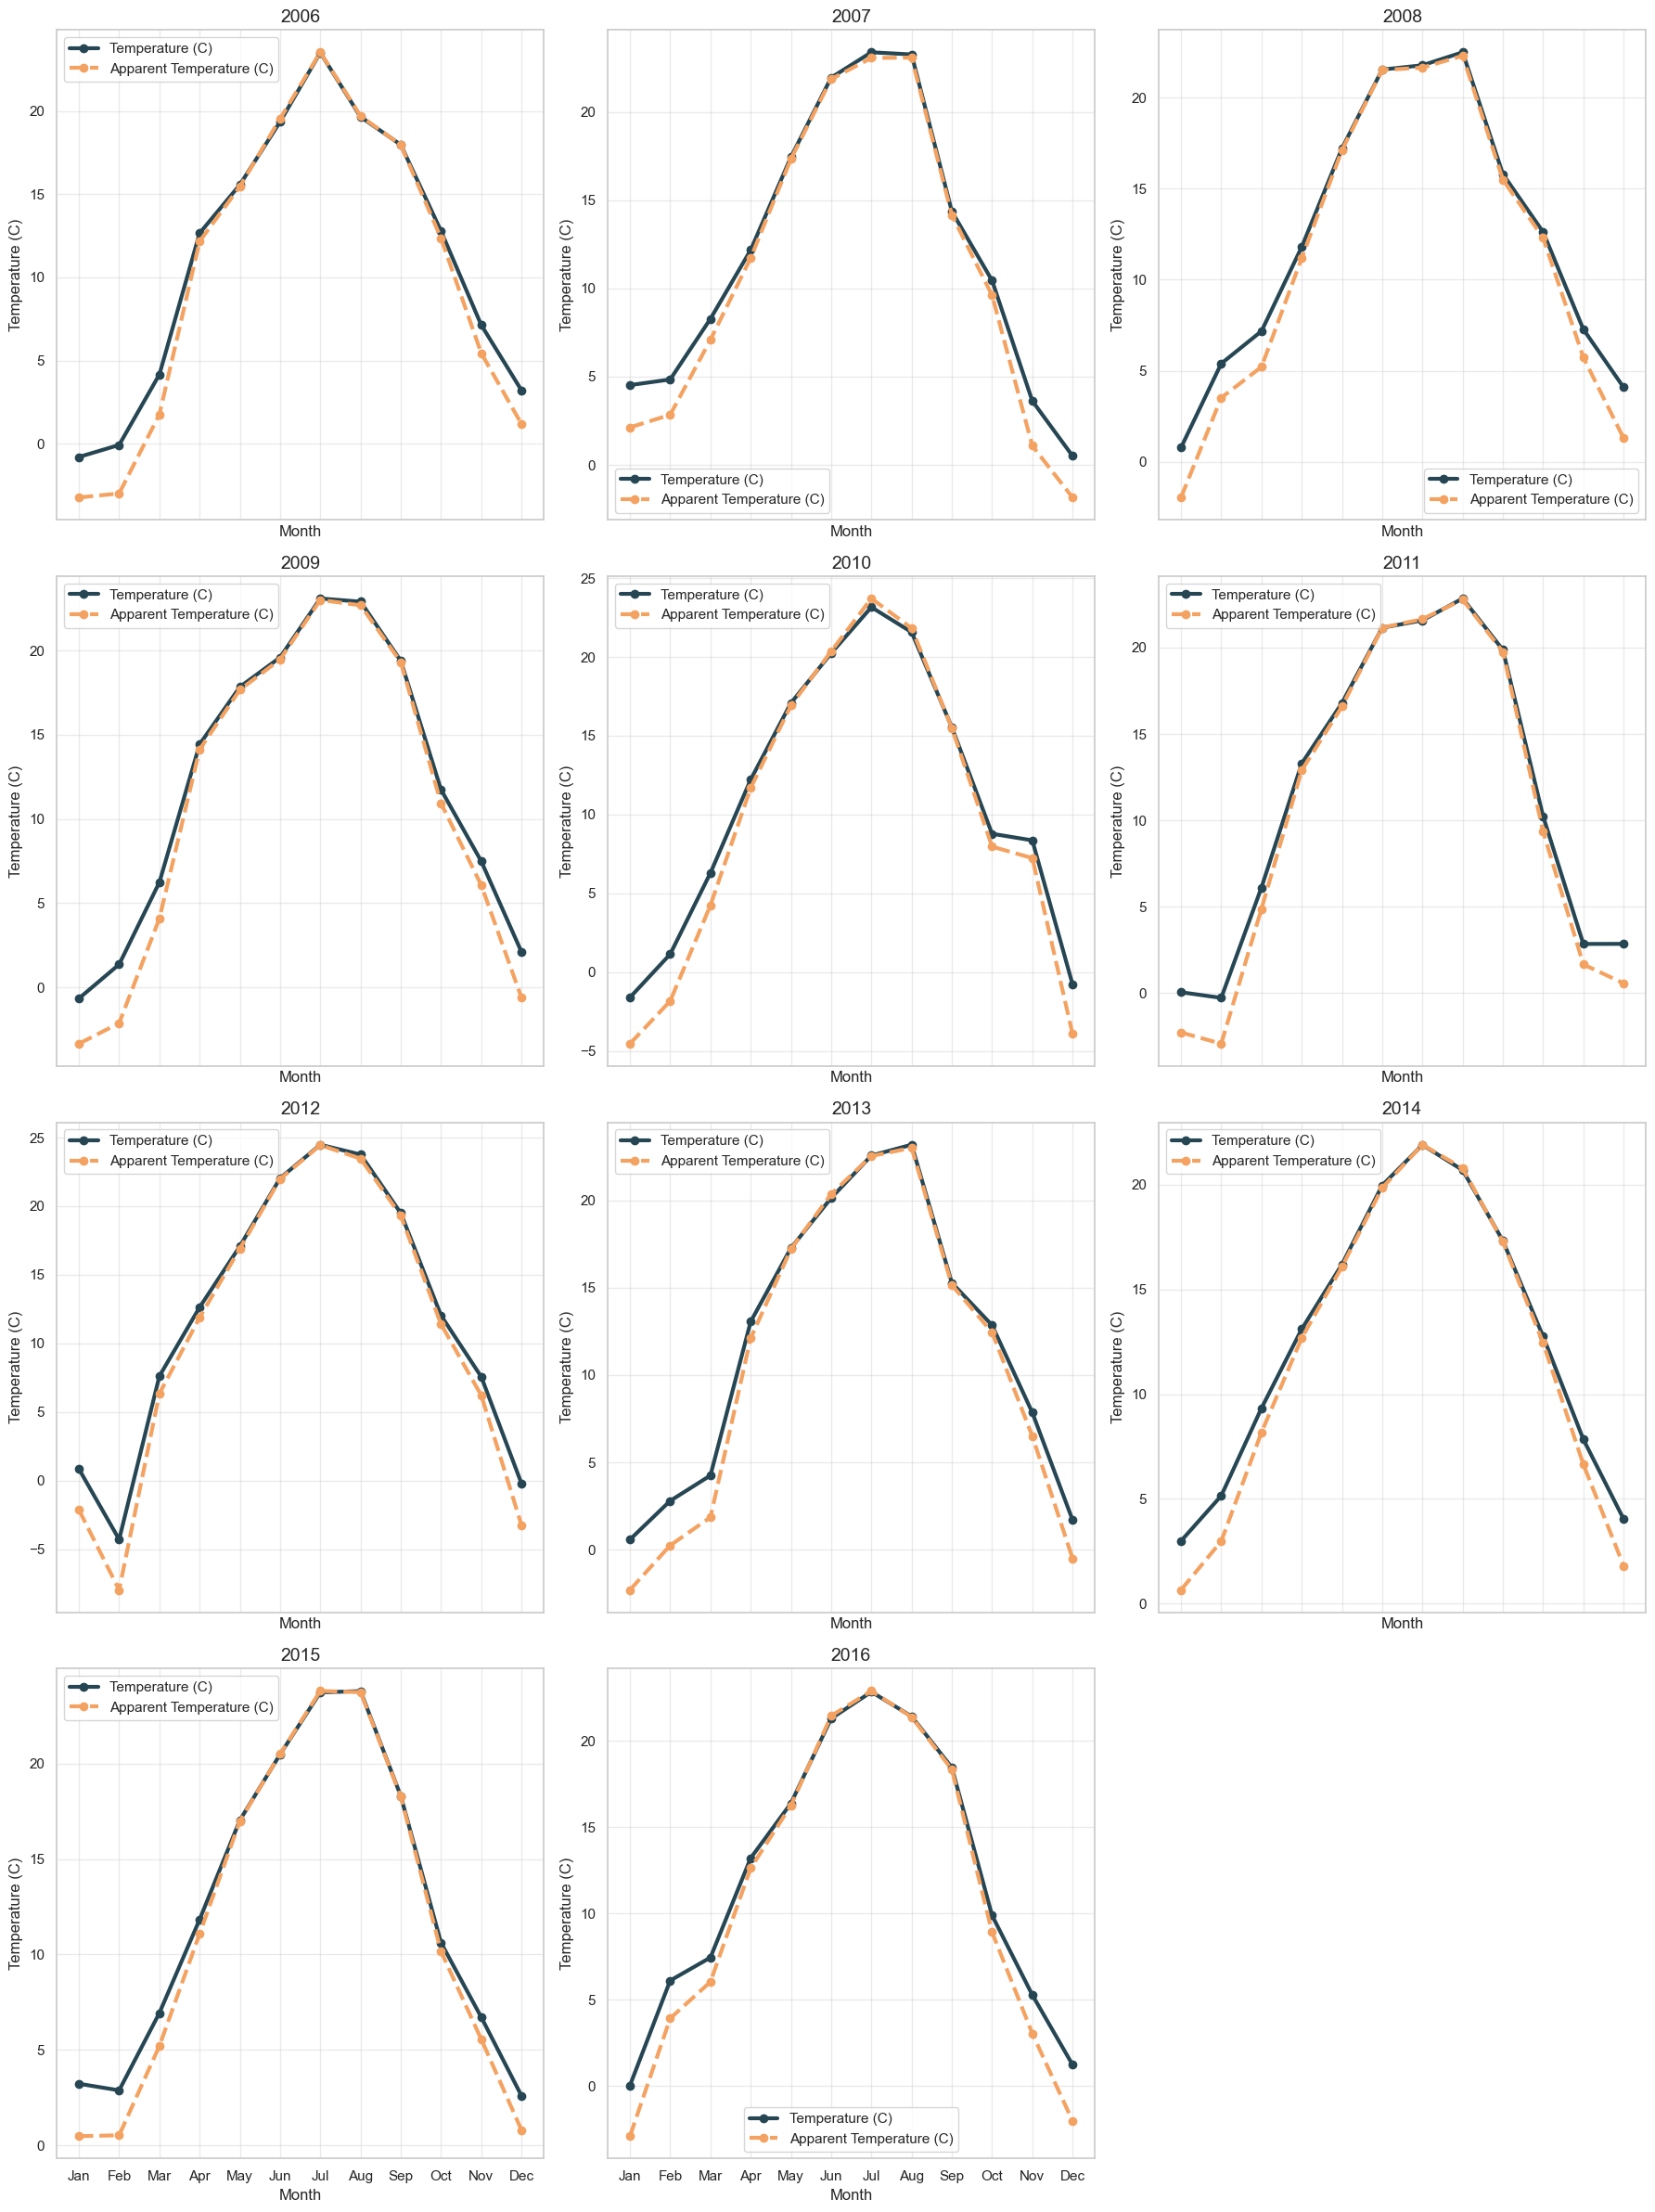

In [34]:
# Extract the unique years in the dataset
years = [2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016]

# Create subplots with specified rows and columns
fig, axes = plt.subplots(4, 3, figsize=(18, 6 * 4), sharex=True)

# Flatten axes to a 1D array for easy indexing
axes = axes.flatten()

for i, year in enumerate(sorted(years)):
    # Filter data for the specific year
    data_year = df_cleaned[df_cleaned['Formatted Date'].dt.year == year]
    
    # Group by month and calculate the mean temperature and apparent temperature
    monthly_avg_temp = data_year.groupby(data_year['Formatted Date'].dt.month)['Temperature (C)'].mean()
    monthly_avg_app_temp = data_year.groupby(data_year['Formatted Date'].dt.month)['Apparent Temperature (C)'].mean()
    
    # Plot on the respective subplot
    ax = axes[i]  # Get the corresponding subplot
    ax.plot(monthly_avg_temp, label='Temperature (C)', color='#264653', marker='o', linewidth=3)
    ax.plot(monthly_avg_app_temp, label='Apparent Temperature (C)', color='#f4a261', marker='o', linestyle='--', linewidth=3)
    
    # Customize each subplot
    ax.set_title(f'{year}', fontsize=14)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Temperature (C)', fontsize=12)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.legend()
    ax.grid(alpha=0.4)

# Turn off any unused subplots
for i in range(len(years), len(axes)):
    fig.delaxes(axes[i])

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()



5- Area charts were used to visualize trends in wind speed between 2010 and 2016, showing consistent patterns of higher wind speeds in specific months.

- How wind speed changes over time?

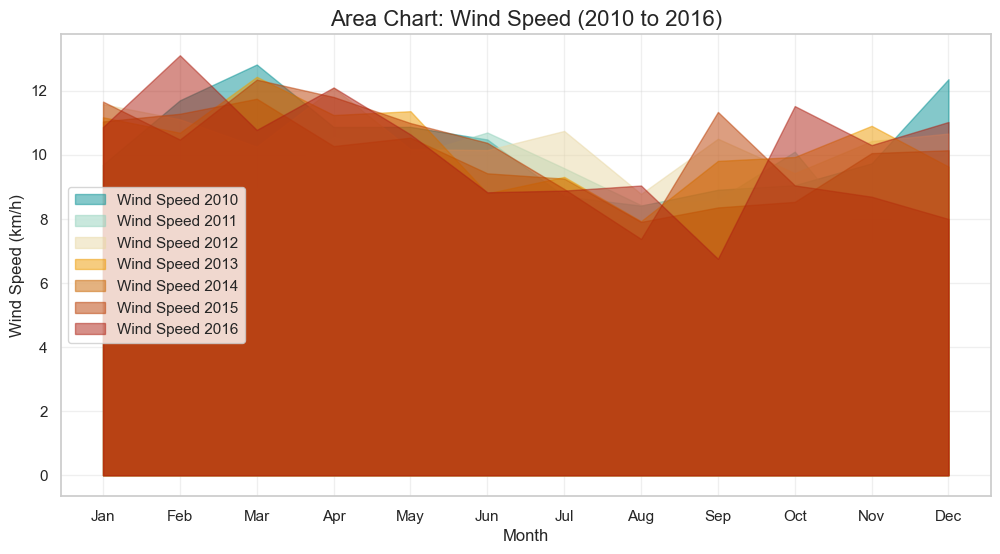

In [35]:
# Extract the year and month from the 'Formatted Date' column

df_cleaned['Year'] = pd.to_datetime(df_cleaned['Formatted Date']).dt.year
df_cleaned['Month'] = pd.to_datetime(df_cleaned['Formatted Date']).dt.month

# Filter data for the years 2010 to 2016
years_of_interest = list(range(2010, 2017))  # 2010 to 2016
df_filtered = df_cleaned[df_cleaned['Year'].isin(years_of_interest)]

colors = colors = ['#0a9396', '#94d2bd', '#e9d8a6', '#ee9b00', '#ca6702', '#bb3e03', '#ae2012'] 

# Calculate monthly average wind speed for each year
monthly_data = df_filtered.groupby(['Year', 'Month'])['Wind Speed (km/h)'].mean()

# Plot the area chart
plt.figure(figsize=(12, 6))

# Plot Wind Speed as areas for each year with custom colors
for i, year in enumerate(years_of_interest):
    year_data = monthly_data.xs(year, level=0)
    plt.fill_between(year_data.index, year_data, color=colors[i], alpha=0.5, label=f'Wind Speed {year}')

# Customize the chart
plt.title('Area Chart: Wind Speed (2010 to 2016)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Wind Speed (km/h)', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(alpha=0.3)

# Show the plot
plt.show()


6- Relationship between Wind Speed and Visibility :

- Correlation between Wind Speed and Visibility : can provide valuable insights into weather dynamics and environmental conditions. 

- A moderate positive correlation (≈0.55) suggested that higher wind speeds generally improve visibility by dispersing fog, smoke, or pollutants.

In [36]:
correlation = df_cleaned['Wind Speed (km/h)'].corr(df_cleaned['Visibility (km)'])
print(f"Correlation between Wind Speed and Visibility: {correlation:.2f}")

Correlation between Wind Speed and Visibility: 0.09


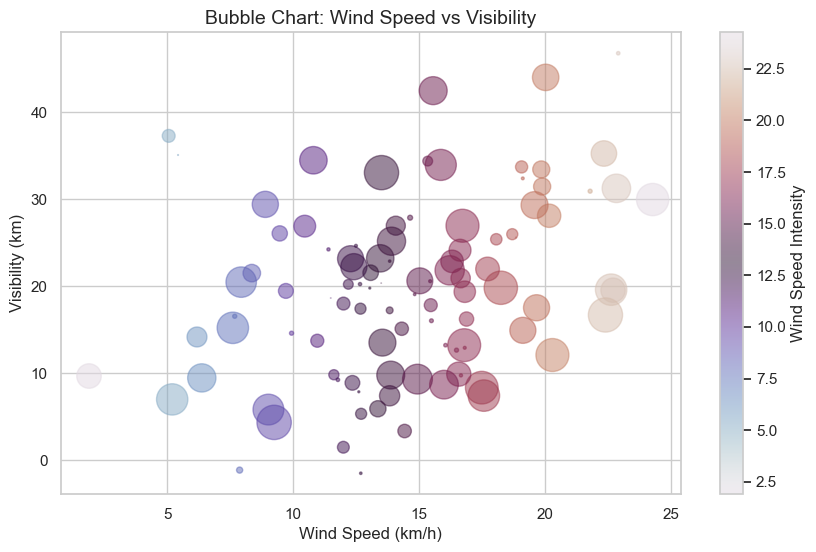

In [37]:

# Sample data for wind speed and visibility
np.random.seed(42)
N = 100
wind_speed = np.random.normal(15, 5, N)  # Simulating wind speed (in km/h)
visibility = wind_speed + np.random.normal(5, 10, N)  # Simulating visibility (in km)
colors = np.random.rand(N)  # Random colors for each point
area = (25 * np.random.rand(N)) ** 2  # Random bubble sizes

# Creating a DataFrame for wind speed and visibility
df_cleaned = pd.DataFrame({
    'Wind Speed (km/h)': wind_speed, 
    'Visibility (km)': visibility, 
    'Colors': colors, 
    'Bubble Size': area
})

# Creating the bubble chart
plt.figure(figsize=(10, 6))  # Set figure size for better clarity
plt.scatter('Wind Speed (km/h)', 'Visibility (km)', 
            s='Bubble Size', alpha=0.5, data=df_cleaned, 
            c='Wind Speed (km/h)', cmap='twilight')  # Gradient based on wind speed

# Adding aesthetics
plt.title('Bubble Chart: Wind Speed vs Visibility', fontsize=14)
plt.xlabel('Wind Speed (km/h)', fontsize=12)
plt.ylabel('Visibility (km)', fontsize=12)
plt.colorbar(label='Wind Speed Intensity')  # Colorbar for wind speed intensity

# Show the plot
plt.show()


7- Pie Chart for Precip Type :

- The distribution of precipitation types was shown, with rain being the most frequent and snow being less common.


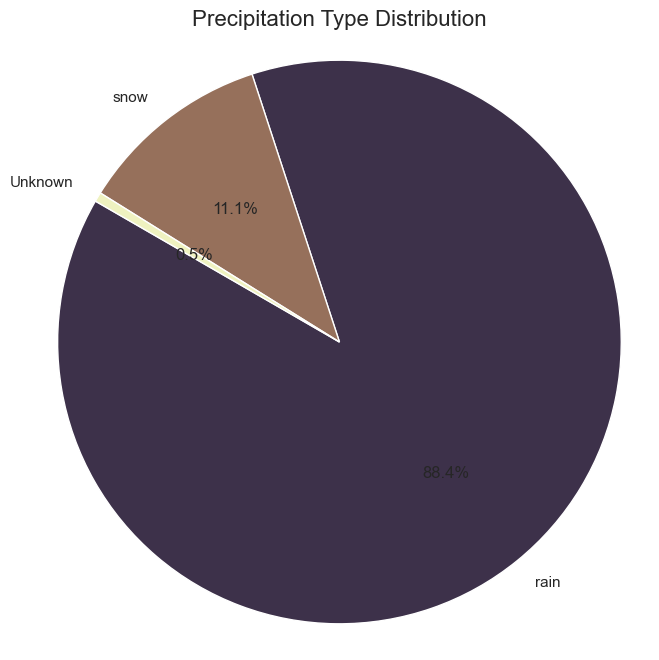

In [38]:
# Count the frequency of each Precip Type
precip_counts = df['Precip Type'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(precip_counts, labels=precip_counts.index, autopct='%1.1f%%', startangle=150, colors=['#3d314a', '#96705b', '#eff2c0', '#a4bab7'])
plt.title('Precipitation Type Distribution', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.show()


Conclusions

Insights Gained

- Seasonality:

Clear seasonal trends in temperature and wind speed can inform long-term planning for industries like agriculture, construction, and tourism.

- Weather Patterns:

The prevalence of rain highlights the need for infrastructure planning to mitigate rain-related disruptions.

- Correlations:

Strong correlations between temperature and apparent temperature can improve the accuracy of weather predictions and their interpretation for public use.

______

Applications of the Analysis

- Weather Forecasting:

Understanding correlations and patterns enhances the accuracy of weather models and predictions.

- Urban Planning:

Insights into wind speeds, precipitation types, and temperature can assist in designing resilient infrastructure.

- Agriculture:

Farmers can use seasonal trends to plan crop cycles and irrigation schedules.

- Transportation and Aviation:

Visibility and wind speed analyses are critical for transportation safety and efficiency.